In [1]:
#Connect With Drive
from google.colab import drive
drive.mount('/content/drive')



Mounted at /content/drive


In [2]:
#Import Modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [3]:
# improt dataset
churn_data=pd.read_csv(r"/content/drive/MyDrive/Churn_data.csv")
customer_data=pd.read_csv(r"/content/drive/MyDrive/Customer_data.csv")
internet_data=pd.read_csv(r"/content/drive/MyDrive/internet_data.csv")

In [4]:
# merge 3 datasets with "customer_id" column
df=pd.merge(churn_data,customer_data,on="customerID")
df=pd.merge(internet_data,df,on="customerID")

In [5]:
# head
df.head()

,customerID,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,tenure,...,MonthlyCharges,TotalCharges,Churn,gender,SeniorCitizen,Partner,Dependents,Day,year,month
0,7590-VHVEG,No phone service,DSL,No,Yes,No,No,No,No,1,...,29.85,29.85,No,Female,NaN,Yes,No,29,1998,1
1,5575-GNVDE,No,DSL,Yes,No,Yes,No,No,No,34,...,56.95,1889.5,No,Male,NaN,No,No,12,1983,9
2,3668-QPYBK,No,DSL,Yes,Yes,No,No,No,No,2,...,53.85,108.15,Yes,Male,NaN,No,No,15,1996,5
3,7795-CFOCW,No phone service,DSL,Yes,No,Yes,Yes,No,No,45,...,42.30,1840.75,No,Male,NaN,No,No,19,2001,2
4,9237-HQITU,No,Fiber optic,No,No,No,No,No,No,2,...,70.70,151.65,Yes,Female,NaN,No,No,23,1980,12


In [6]:
# tail
df.tail()

,customerID,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,tenure,...,MonthlyCharges,TotalCharges,Churn,gender,SeniorCitizen,Partner,Dependents,Day,year,month
7038,6840-RESVB,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,24,...,84.80,1990.5,No,Male,NaN,Yes,Yes,23,2011,9
7039,2234-XADUH,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,72,...,103.20,7362.9,No,Female,NaN,Yes,Yes,25,2010,11
7040,4801-JZAZL,No phone service,DSL,Yes,No,No,No,No,No,11,...,29.60,346.45,No,Female,NaN,Yes,Yes,3,1998,3
7041,8361-LTMKD,Yes,Fiber optic,No,No,No,No,No,No,4,...,74.40,306.6,Yes,Male,NaN,Yes,No,28,1997,3
7042,3186-AJIEK,No,Fiber optic,Yes,No,Yes,Yes,Yes,Yes,66,...,105.65,6844.5,No,Male,NaN,No,No,2,1994,1


In [7]:
# info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   MultipleLines     7043 non-null   object 
 2   InternetService   7043 non-null   object 
 3   OnlineSecurity    5517 non-null   object 
 4   OnlineBackup      5517 non-null   object 
 5   DeviceProtection  5517 non-null   object 
 6   TechSupport       5517 non-null   object 
 7   StreamingTV       5517 non-null   object 
 8   StreamingMovies   5517 non-null   object 
 9   tenure            7043 non-null   int64  
 10  PhoneService      7043 non-null   object 
 11  Contract          7043 non-null   object 
 12  PaperlessBilling  7043 non-null   object 
 13  PaymentMethod     7043 non-null   object 
 14  MonthlyCharges    7043 non-null   float64
 15  TotalCharges      7043 non-null   object 
 16  Churn             7043 non-null   object 


In [8]:
#calculate null values
df.isnull().sum()/len(df.index)*100

,0
customerID,0.000000
MultipleLines,0.000000
InternetService,0.000000
OnlineSecurity,21.666903
OnlineBackup,21.666903
DeviceProtection,21.666903
TechSupport,21.666903
StreamingTV,21.666903
StreamingMovies,21.666903
tenure,0.000000


In [9]:
# statistics
df.describe()

,tenure,MonthlyCharges,SeniorCitizen,Day,year,month
count,7043.000000,7043.000000,0.0,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,NaN,15.443277,1996.036490,6.563396
std,24.559481,30.090047,NaN,8.693037,9.505657,3.432856
min,0.000000,18.250000,NaN,1.000000,1980.000000,1.000000
25%,9.000000,35.500000,NaN,8.000000,1988.000000,4.000000
50%,29.000000,70.350000,NaN,16.000000,1996.000000,7.000000
75%,55.000000,89.850000,NaN,23.000000,2004.000000,10.000000
max,72.000000,118.750000,NaN,30.000000,2012.000000,12.000000


In [10]:
# column names
df.columns

Index(['customerID', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'tenure', 'PhoneService', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges',
       'Churn', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'Day',
       'year', 'month'],
      dtype='object')

In [11]:
# shape
df.shape

(7043, 24)

# **DATA CLEANING**

In [12]:
# Replace empty strings with NaN
df["TotalCharges"] = df["TotalCharges"].replace(' ', np.nan)
# Convert TotalCharges to float
df["TotalCharges"] = df["TotalCharges"].astype("float")

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   MultipleLines     7043 non-null   object 
 2   InternetService   7043 non-null   object 
 3   OnlineSecurity    5517 non-null   object 
 4   OnlineBackup      5517 non-null   object 
 5   DeviceProtection  5517 non-null   object 
 6   TechSupport       5517 non-null   object 
 7   StreamingTV       5517 non-null   object 
 8   StreamingMovies   5517 non-null   object 
 9   tenure            7043 non-null   int64  
 10  PhoneService      7043 non-null   object 
 11  Contract          7043 non-null   object 
 12  PaperlessBilling  7043 non-null   object 
 13  PaymentMethod     7043 non-null   object 
 14  MonthlyCharges    7043 non-null   float64
 15  TotalCharges      7032 non-null   float64
 16  Churn             7043 non-null   object 


In [14]:
# drop seniorcitizen column
df=df.drop(["SeniorCitizen"],axis=1)

In [15]:
df.shape

(7043, 23)

In [16]:
# change columns name(partner to SeniorCitizen & dependents to partner_dependents)
df=df.rename(columns={"Partner":"SeniorCitizen"})
df=df.rename(columns={"Dependents":"partner_dependents"})
df.head(1)

,customerID,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,tenure,...,PaymentMethod,MonthlyCharges,TotalCharges,Churn,gender,SeniorCitizen,partner_dependents,Day,year,month
0,7590-VHVEG,No phone service,DSL,No,Yes,No,No,No,No,1,...,Electronic check,29.85,29.85,No,Female,Yes,No,29,1998,1


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 23 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customerID          7043 non-null   object 
 1   MultipleLines       7043 non-null   object 
 2   InternetService     7043 non-null   object 
 3   OnlineSecurity      5517 non-null   object 
 4   OnlineBackup        5517 non-null   object 
 5   DeviceProtection    5517 non-null   object 
 6   TechSupport         5517 non-null   object 
 7   StreamingTV         5517 non-null   object 
 8   StreamingMovies     5517 non-null   object 
 9   tenure              7043 non-null   int64  
 10  PhoneService        7043 non-null   object 
 11  Contract            7043 non-null   object 
 12  PaperlessBilling    7043 non-null   object 
 13  PaymentMethod       7043 non-null   object 
 14  MonthlyCharges      7043 non-null   float64
 15  TotalCharges        7032 non-null   float64
 16  Churn 

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 23 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customerID          7043 non-null   object 
 1   MultipleLines       7043 non-null   object 
 2   InternetService     7043 non-null   object 
 3   OnlineSecurity      5517 non-null   object 
 4   OnlineBackup        5517 non-null   object 
 5   DeviceProtection    5517 non-null   object 
 6   TechSupport         5517 non-null   object 
 7   StreamingTV         5517 non-null   object 
 8   StreamingMovies     5517 non-null   object 
 9   tenure              7043 non-null   int64  
 10  PhoneService        7043 non-null   object 
 11  Contract            7043 non-null   object 
 12  PaperlessBilling    7043 non-null   object 
 13  PaymentMethod       7043 non-null   object 
 14  MonthlyCharges      7043 non-null   float64
 15  TotalCharges        7032 non-null   float64
 16  Churn 

In [68]:
# replace NAN values with average value
df["TotalCharges"]=df["TotalCharges"].fillna(df["TotalCharges"].mean())

In [20]:
# replace empty cells with "Data Not Provide"
df[["InternetService","OnlineSecurity","OnlineBackup","DeviceProtection","TechSupport","StreamingTV","StreamingMovies"]]= df[["InternetService","OnlineSecurity",
                                            "OnlineBackup","DeviceProtection","TechSupport","StreamingTV","StreamingMovies"]].fillna("Data Not Provided")

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 23 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customerID          7043 non-null   object 
 1   MultipleLines       7043 non-null   object 
 2   InternetService     7043 non-null   object 
 3   OnlineSecurity      7043 non-null   object 
 4   OnlineBackup        7043 non-null   object 
 5   DeviceProtection    7043 non-null   object 
 6   TechSupport         7043 non-null   object 
 7   StreamingTV         7043 non-null   object 
 8   StreamingMovies     7043 non-null   object 
 9   tenure              7043 non-null   int64  
 10  PhoneService        7043 non-null   object 
 11  Contract            7043 non-null   object 
 12  PaperlessBilling    7043 non-null   object 
 13  PaymentMethod       7043 non-null   object 
 14  MonthlyCharges      7043 non-null   float64
 15  TotalCharges        7043 non-null   float64
 16  Churn 

In [70]:
df['tenure_group'] = pd.cut(
    df['tenure'],
    bins=[0,12,24,36,48,60,72,100],
    labels=['0-12','13-24','25-36','37-48','49-60','61-72','72+'],
    include_lowest=True
)

In [24]:
df.isnull().sum()/len(df.index)*100

,0
customerID,0.0
MultipleLines,0.0
InternetService,0.0
OnlineSecurity,0.0
OnlineBackup,0.0
DeviceProtection,0.0
TechSupport,0.0
StreamingTV,0.0
StreamingMovies,0.0
tenure,0.0


# **EDA**

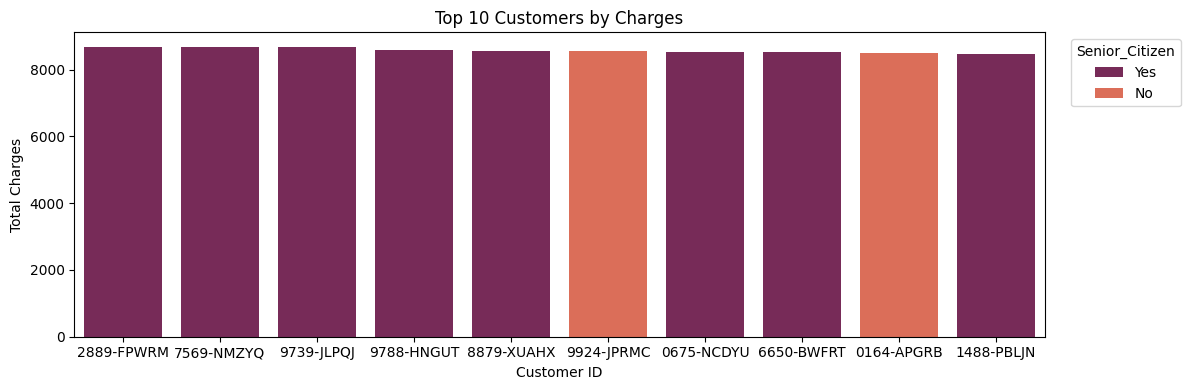

In [25]:
#1)top 10 customer_id by charges
top_customers=df.groupby(["customerID","SeniorCitizen"])["TotalCharges"].sum().sort_values(ascending=False).reset_index().head(10)
plt.figure(figsize=(12,4))
sns.barplot(data=top_customers,x="customerID",y="TotalCharges",hue="SeniorCitizen",palette="rocket")
plt.legend(title="Senior_Citizen",loc="upper left", bbox_to_anchor=(1.02, 1))
plt.xlabel("Customer ID")
plt.ylabel("Total Charges")
plt.title("Top 10 Customers by Charges")
plt.tight_layout()
plt.show()

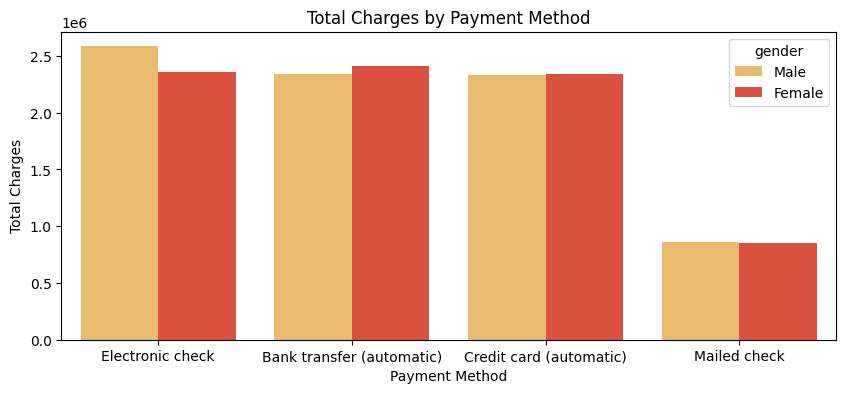

In [26]:
# total charges by PaymentMethod
payment_mode=df.groupby(["PaymentMethod","gender"])["TotalCharges"].sum().sort_values(ascending=False).reset_index()
plt.figure(figsize=(10,4))
sns.barplot(data=payment_mode,x="PaymentMethod",y="TotalCharges",hue="gender",palette="YlOrRd")
plt.xlabel("Payment Method")
plt.ylabel("Total Charges")
plt.title("Total Charges by Payment Method")
plt.show()

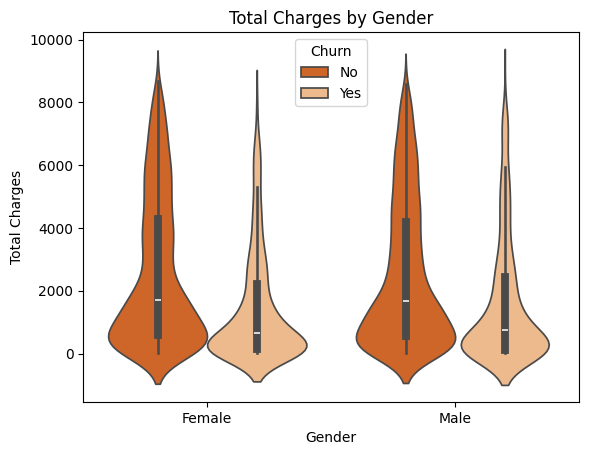

In [27]:
# gender wise total charges
sns.violinplot(data=df,x="gender",y="TotalCharges",palette="Oranges_r",hue="Churn")
plt.xlabel("Gender")
plt.ylabel("Total Charges")
plt.title("Total Charges by Gender")
plt.show()

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

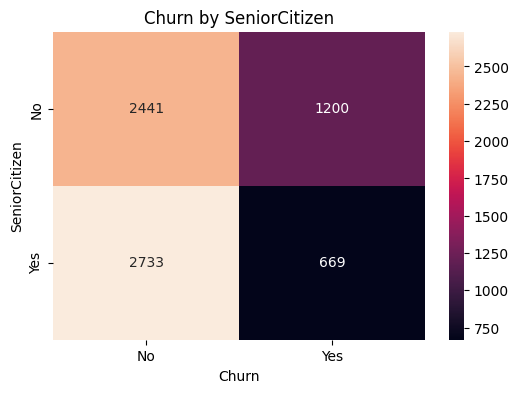

In [28]:
# SeniorCitizen wise churn
cross_tab=pd.crosstab(df["SeniorCitizen"],df["Churn"])
plt.figure(figsize=(6,4))
sns.heatmap(cross_tab,annot=True,fmt="d")
plt.xlabel("Churn")
plt.ylabel("SeniorCitizen")
plt.title("Churn by SeniorCitizen")
plt

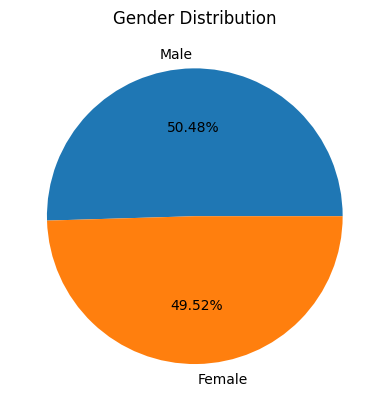

In [29]:
# gender distibution
gender_distribution=df["gender"].value_counts().sort_values(ascending=False)
plt.pie(gender_distribution.values,labels=gender_distribution.index,autopct="%.2f%%")
plt.title("Gender Distribution")
plt.show()

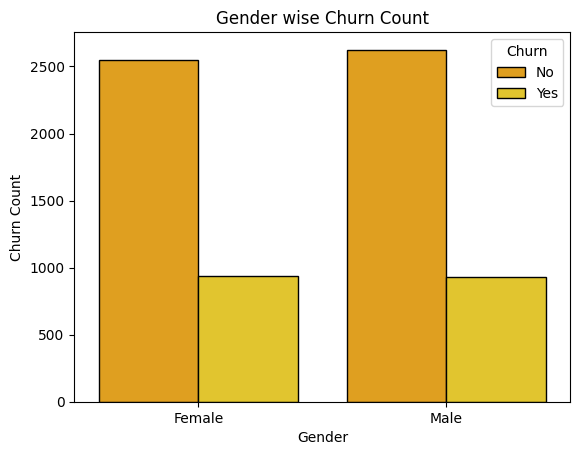

In [30]:
# gender wise churn count
gender_wise_churn=df.groupby(["gender","Churn"])["customerID"].count().reset_index()
sns.barplot(data=gender_wise_churn,x="gender",y="customerID",hue="Churn",palette="Wistia_r",edgecolor="black")
plt.xlabel("Gender")
plt.ylabel("Churn Count")
plt.title("Gender wise Churn Count")
plt.show()

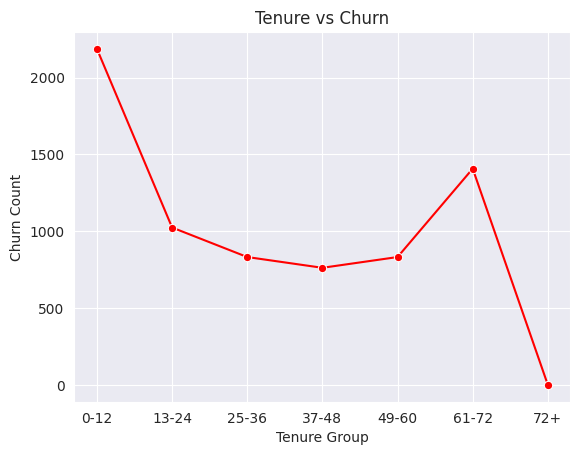

In [71]:
# tenure vs churn
tenure_wise_churn=df.groupby(["tenure_group"])["Churn"].count().reset_index()
sns.set_style("darkgrid")
sns.lineplot(data=tenure_wise_churn,x="tenure_group",y="Churn",color="red",marker="o")
plt.xlabel("Tenure Group")
plt.ylabel("Churn Count")
plt.title("Tenure vs Churn")
plt.show()

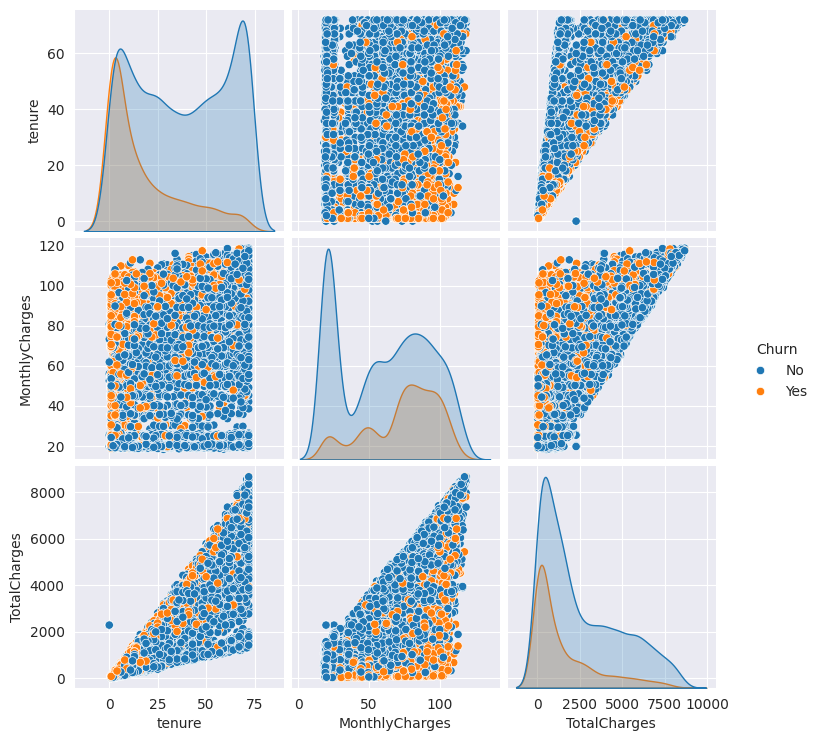

In [32]:
sns.pairplot(df, vars=["tenure","MonthlyCharges","TotalCharges"], hue="Churn")

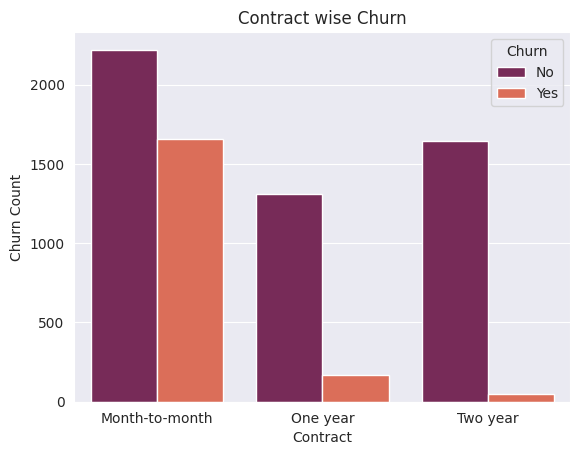

In [33]:
# contract wise churn
contract_wise_churn=df.groupby(["Contract","Churn"])["customerID"].count().reset_index()
sns.barplot(data=contract_wise_churn,x="Contract",y="customerID",hue="Churn",palette="rocket")
plt.xlabel("Contract")
plt.ylabel("Churn Count")
plt.title("Contract wise Churn")
plt.show()

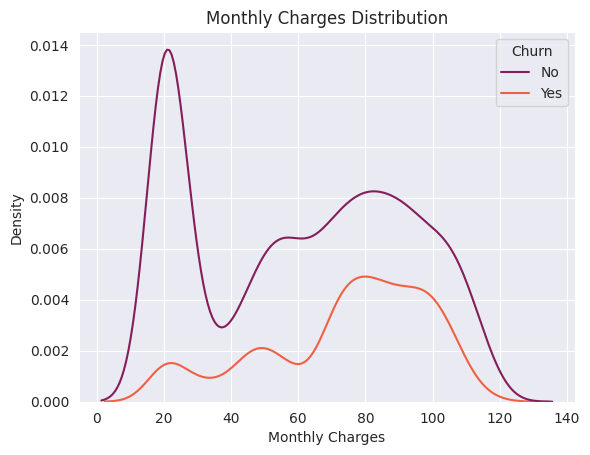

In [34]:
#monthly charges distribution
sns.kdeplot(data=df,x="MonthlyCharges",hue="Churn",palette="rocket")
sns.set_style("whitegrid")
plt.xlabel("Monthly Charges")
plt.ylabel("Density")
plt.title("Monthly Charges Distribution")
plt.show()

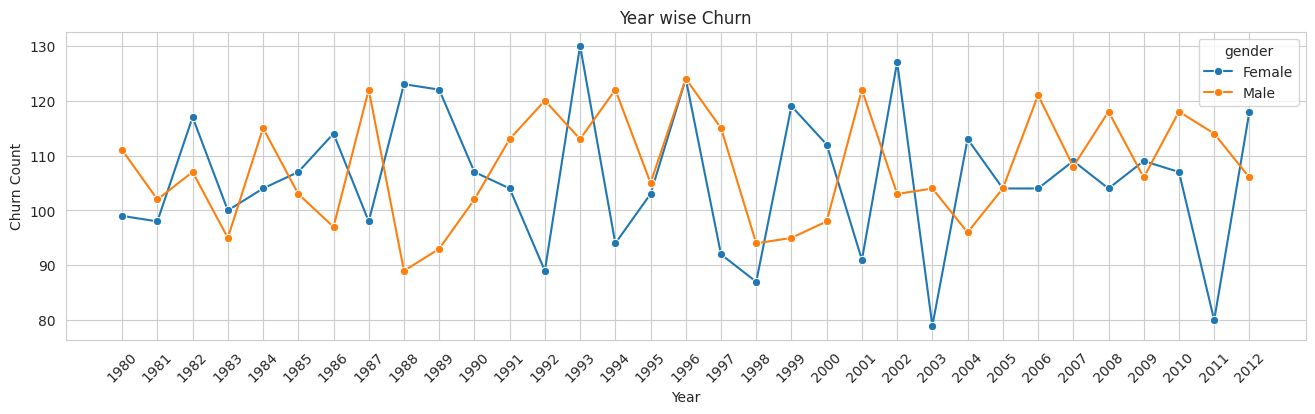

In [35]:
# year wise churn
year_wise_churn=df.groupby(["year","gender"])["Churn"].count().reset_index()
plt.figure(figsize=(16,4))
sns.set_style("whitegrid")
sns.lineplot(data=year_wise_churn,x="year",y="Churn",hue="gender",marker="o")
plt.xlabel("Year")
plt.ylabel("Churn Count")
plt.title("Year wise Churn")
plt.xticks(year_wise_churn['year'].unique(), rotation=45)
plt.show()

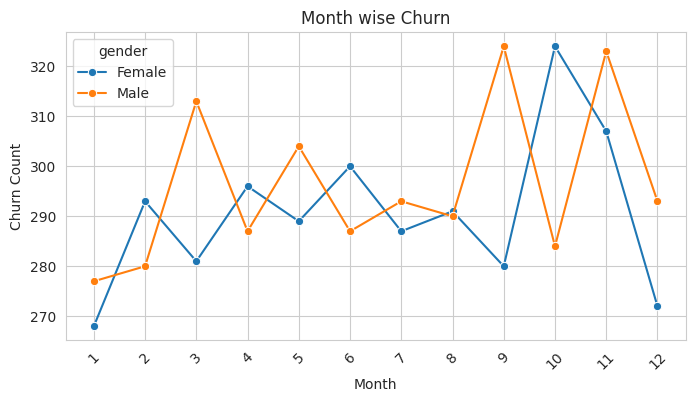

In [36]:
# month wise churn
month_wise_churn=df.groupby(["month","gender"])["Churn"].count().reset_index()
plt.figure(figsize=(8,4))
sns.lineplot(data=month_wise_churn,x="month",y="Churn",hue="gender",marker="o")
plt.xlabel("Month")
plt.ylabel("Churn Count")
plt.title("Month wise Churn")
plt.xticks(month_wise_churn['month'].unique(), rotation=45)
plt.show()

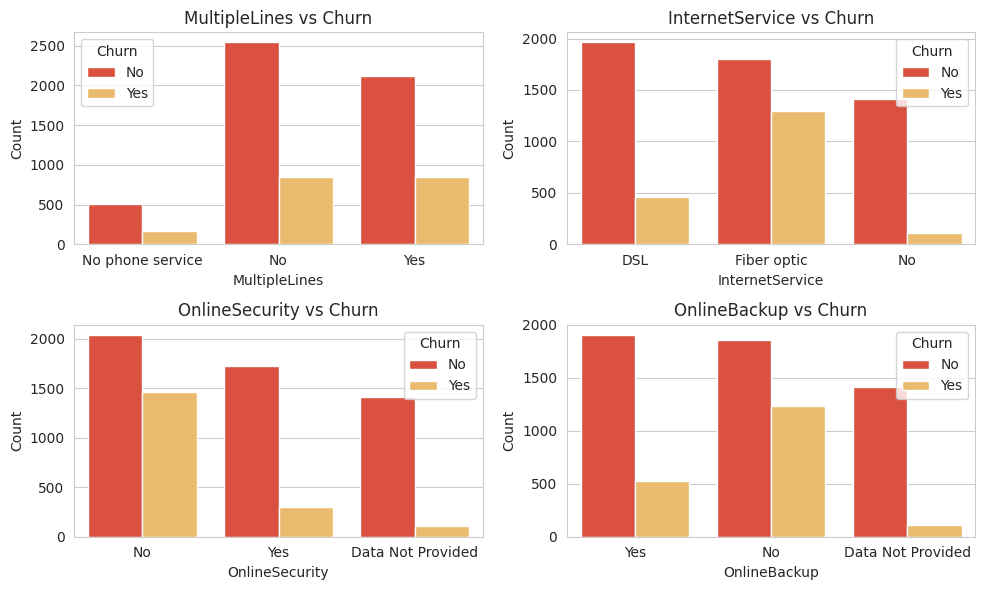

In [64]:
# churn analysis with subplots
fig, axs = plt.subplots(2,2,figsize=(10,6))
sns.countplot(data=df, x="MultipleLines", hue="Churn", ax=axs[0,0],palette="YlOrRd_r")
axs[0, 0].set_title("MultipleLines vs Churn")
axs[0, 0].set_ylabel("Count")

sns.countplot(data=df, x="InternetService", hue="Churn", ax=axs[0,1],palette="YlOrRd_r")
axs[0, 1].set_title("InternetService vs Churn")
axs[0, 1].set_ylabel("Count")

sns.countplot(data=df, x="OnlineSecurity", hue="Churn", ax=axs[1,0],palette="YlOrRd_r")
axs[1, 0].set_title("OnlineSecurity vs Churn")
axs[1, 0].set_ylabel("Count")

sns.countplot(data=df, x="OnlineBackup", hue="Churn", ax=axs[1,1],palette="YlOrRd_r")
axs[1, 1].set_title("OnlineBackup vs Churn")
axs[1, 1].set_ylabel("Count")

plt.tight_layout()
plt.show()

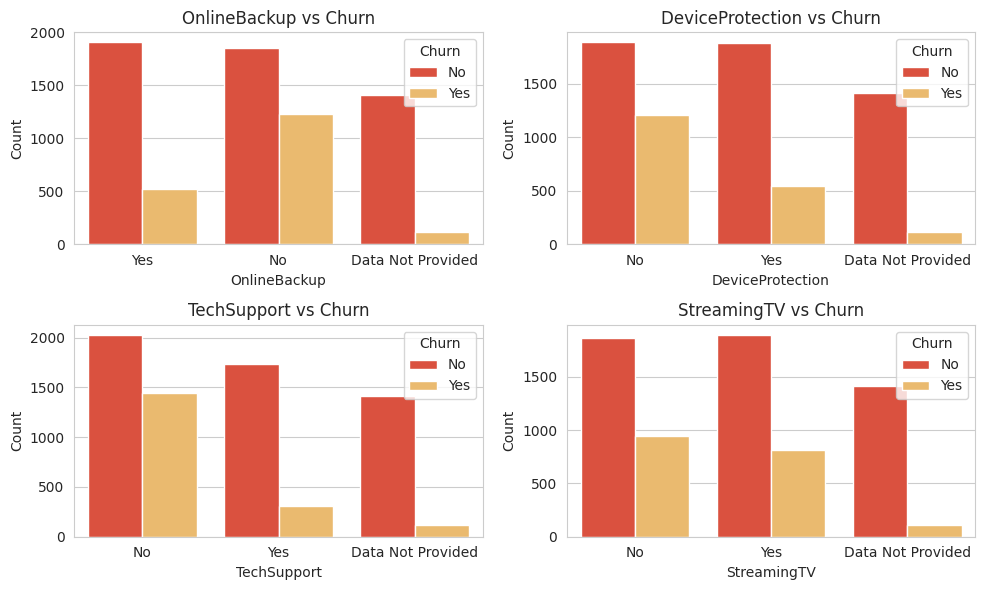

In [65]:
fig1,axs1=plt.subplots(2,2,figsize=(10,6))
sns.countplot(data=df,x="OnlineBackup",hue="Churn",ax=axs1[0,0],palette="YlOrRd_r")
axs1[0,0].set_title("OnlineBackup vs Churn")
axs1[0,0].set_ylabel("Count")

sns.countplot(data=df,x="DeviceProtection",hue="Churn",ax=axs1[0,1],palette="YlOrRd_r")
axs1[0,1].set_title("DeviceProtection vs Churn")
axs1[0,1].set_ylabel("Count")

sns.countplot(data=df,x="TechSupport",hue="Churn",ax=axs1[1,0],palette="YlOrRd_r")
axs1[1,0].set_title("TechSupport vs Churn")
axs1[1,0].set_ylabel("Count")

sns.countplot(data=df,x="StreamingTV",hue="Churn",ax=axs1[1,1],palette="YlOrRd_r")
axs1[1,1].set_title("StreamingTV vs Churn")
axs1[1,1].set_ylabel("Count")

plt.tight_layout()
plt.show()

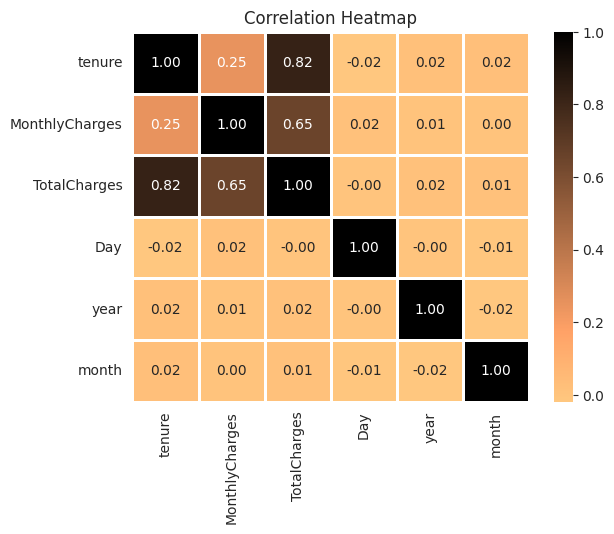

In [39]:
# correlation
numeric=df.select_dtypes(include="number")
corr=numeric.corr()
sns.heatmap(corr,annot=True,fmt=".2f",cmap="copper_r",linewidths=0.8)
plt.title("Correlation Heatmap")
plt.show()

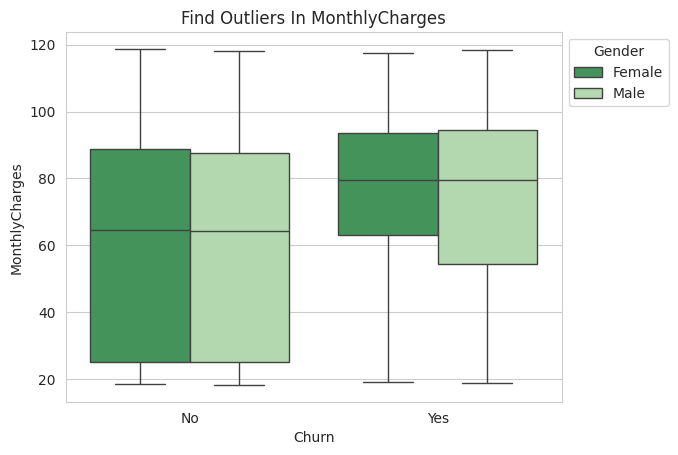

In [66]:
sns.boxplot(data=df,x="Churn",y="MonthlyCharges",hue="gender",palette="Greens_r")
plt.legend(bbox_to_anchor=(1,1), title="Gender", loc='upper left')
plt.xlabel("Churn")
plt.ylabel("MonthlyCharges")
plt.title("Find Outliers In MonthlyCharges")
plt.show()

In [48]:
Q1=df["MonthlyCharges"].quantile(0.25)
Q3=df["MonthlyCharges"].quantile(0.75)
print("Q1:",Q1)
print("Q3:",Q3)
IQR=Q3-Q1
print("IQR:",IQR)
lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR
print("Lower Bound:",lower_bound)
print("Upper Bound:",upper_bound)

Q1: 35.5
Q3: 89.85
IQR: 54.349999999999994
Lower Bound: -46.02499999999999
Upper Bound: 171.375


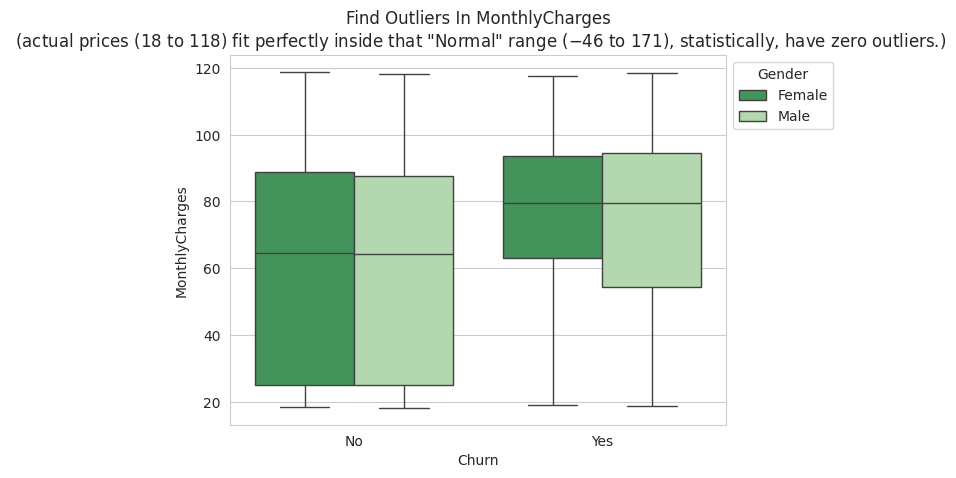

In [67]:
outliers_removed=df[(df["MonthlyCharges"]>=lower_bound) & (df["MonthlyCharges"]<=upper_bound)]
sns.boxplot(data=outliers_removed,x="Churn",y="MonthlyCharges",hue="gender",palette="Greens_r")
plt.legend(bbox_to_anchor=(1,1), title="Gender", loc='upper left')
plt.xlabel("Churn")
plt.ylabel("MonthlyCharges")
plt.title("Find Outliers In MonthlyCharges\n (actual prices ($18$ to $118$) fit perfectly inside that \"Normal\" range ($ -46$ to $171$), statistically, have zero outliers.)")
plt.show()